In [ ]:
# ===============================
# 1) IMPORT LIBRARIES
# ===============================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
 )

Loading Data

In [ ]:
df = pd.read_csv('heart_disease_uci.csv')
print(f"Dataset shape: {df.shape}")

Dataset shape: (920, 16)


Reviewing Dataset

In [ ]:
print(df.head())

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  


Checking missing values

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


Handling Missing Values
-> Filling numerical values with median
-> filling categorical values with mode

In [ ]:
cols_to_fix_median = ['trestbps', 'chol', 'thalch', 'oldpeak']
for col in cols_to_fix_median:
    df[col] = df[col].fillna(df[col].median())

cols_to_fix_mode = ['fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
for col in cols_to_fix_mode:
    mode_value = df[col].mode(dropna=True)[0]
    df[col] = df[col].where(df[col].notna(), mode_value)

Verifing Cleaning

In [ ]:
print("Total missing values left:", df.isnull().sum().sum())
print(df.describe())

Total missing values left: 0
               id         age    trestbps        chol      thalch     oldpeak  \
count  920.000000  920.000000  920.000000  920.000000  920.000000  920.000000   
mean   460.500000   53.510870  131.995652  199.908696  137.692391    0.853261   
std    265.725422    9.424685   18.451300  109.040171   25.145235    1.058049   
min      1.000000   28.000000    0.000000    0.000000   60.000000   -2.600000   
25%    230.750000   47.000000  120.000000  177.750000  120.000000    0.000000   
50%    460.500000   54.000000  130.000000  223.000000  140.000000    0.500000   
75%    690.250000   60.000000  140.000000  267.000000  156.000000    1.500000   
max    920.000000   77.000000  200.000000  603.000000  202.000000    6.200000   

               ca         num      target  
count  920.000000  920.000000  920.000000  
mean     0.227174    0.995652    0.553261  
std      0.628936    1.142693    0.497426  
min      0.000000    0.000000    0.000000  
25%      0.000000    

Create binary target: 0 = healthy, 1 = heart disease

In [ ]:
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

# One-hot encode categorical columns
df_encoded = pd.get_dummies(
    df,
    columns=['sex', 'dataset', 'cp', 'restecg', 'slope', 'thal'],
    drop_first=True
)

# Remove columns not used for modeling
df_encoded = df_encoded.drop(['id', 'num'], axis=1)

print(df_encoded.head())

   age  trestbps   chol    fbs  thalch  exang  oldpeak   ca  target  sex_Male  \
0   63     145.0  233.0   True   150.0  False      2.3  0.0       0      True   
1   67     160.0  286.0  False   108.0   True      1.5  3.0       1      True   
2   67     120.0  229.0  False   129.0   True      2.6  2.0       1      True   
3   37     130.0  250.0  False   187.0  False      3.5  0.0       0      True   
4   41     130.0  204.0  False   172.0  False      1.4  0.0       0     False   

   ...  dataset_VA Long Beach  cp_atypical angina  cp_non-anginal  \
0  ...                  False               False           False   
1  ...                  False               False           False   
2  ...                  False               False           False   
3  ...                  False               False            True   
4  ...                  False                True           False   

   cp_typical angina  restecg_normal  restecg_st-t abnormality  slope_flat  \
0               True

Preparing Data for training and testing

In [ ]:

X = df_encoded.drop(['target'], axis=1)
y = df_encoded['target']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale numerical values for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Training set: (736, 21), Test set: (184, 21)


Visualizing

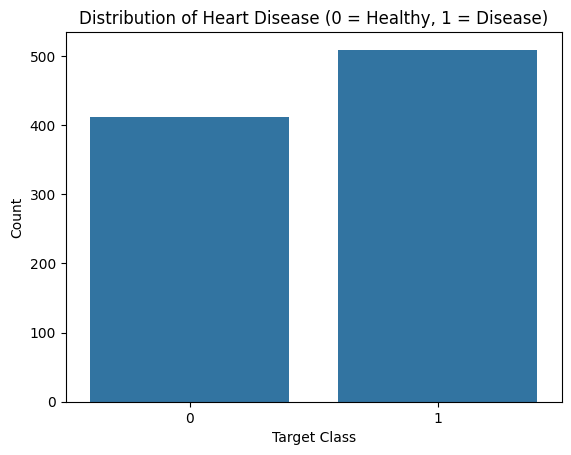

Class counts:
target
1    509
0    411
Name: count, dtype: int64


In [ ]:

sns.countplot(x='target', data=df)
plt.title('Distribution of Heart Disease (0 = Healthy, 1 = Disease)')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()

print("Class counts:")
print(df['target'].value_counts())

Training model(logistic Regression)

In [ ]:

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred = model.predict(X_test_scaled)

# Print core metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 83.15%

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.81      0.80        75
           1       0.87      0.84      0.86       109

    accuracy                           0.83       184
   macro avg       0.82      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184

Confusion Matrix:
[[61 14]
 [17 92]]


Printing Confusion Matrix

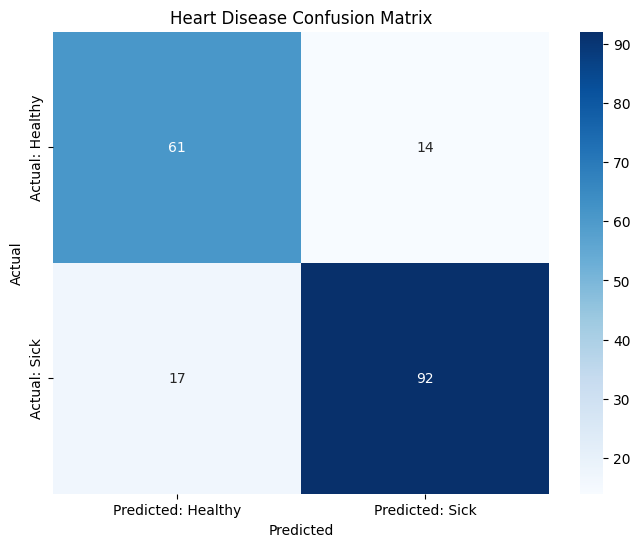

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted: Healthy', 'Predicted: Sick'],
    yticklabels=['Actual: Healthy', 'Actual: Sick']
 )

plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Heart Disease Confusion Matrix')
plt.show()

Plotting ROC Curce

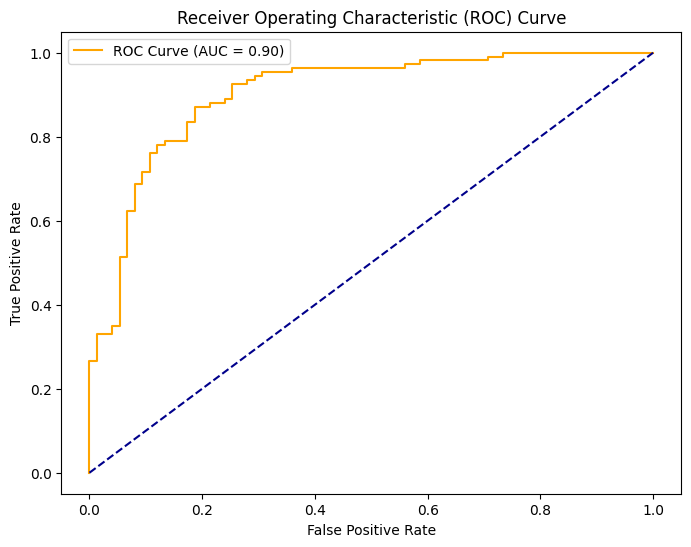

In [ ]:
# Predict probabilities for the positive class
y_probs = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()